Loaded 2200 training pairs


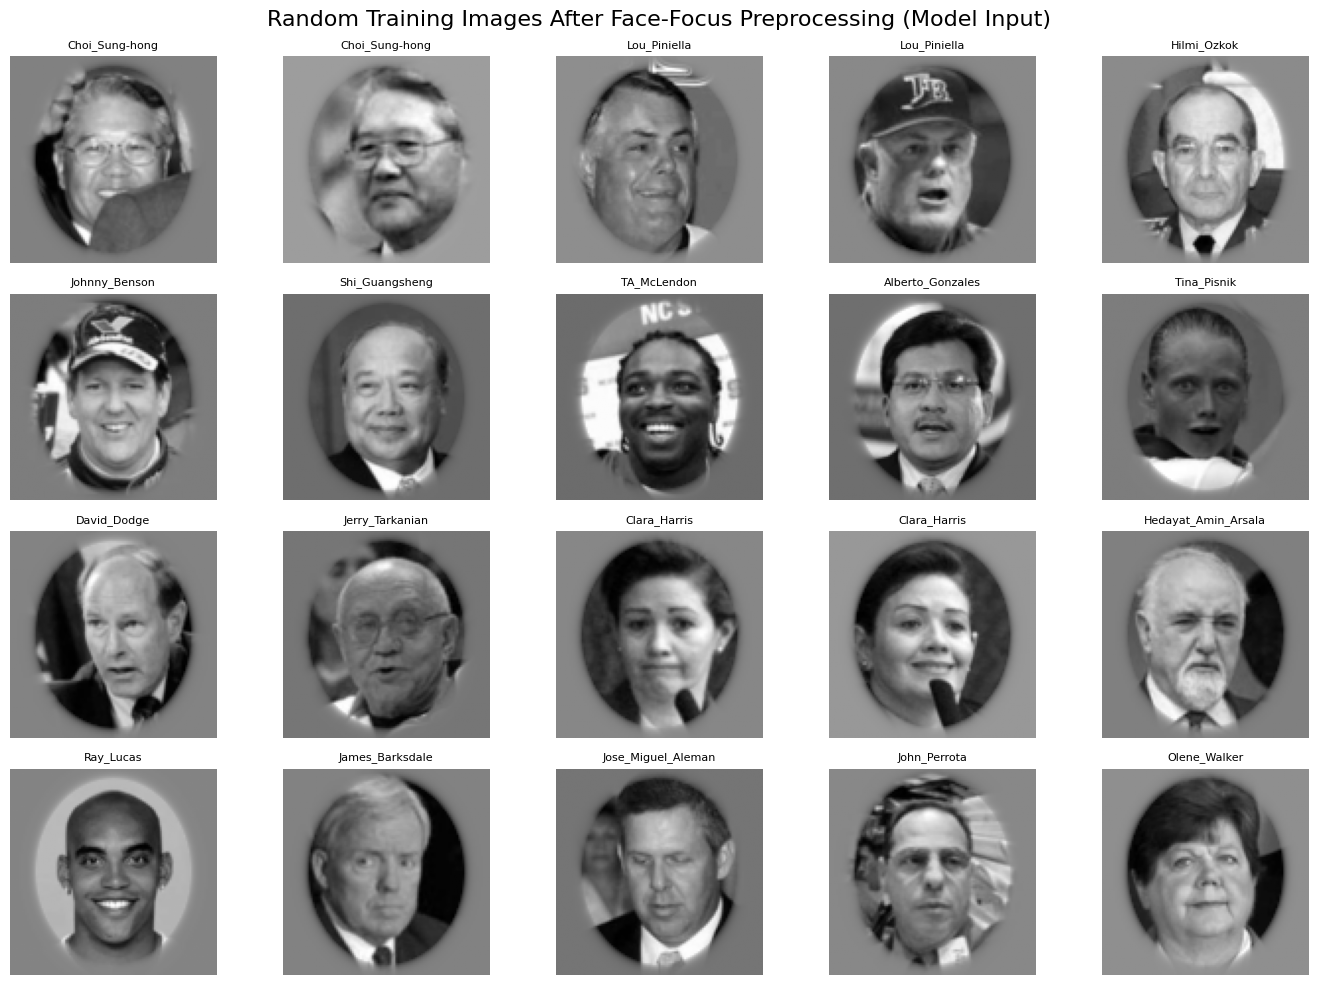

In [3]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from src.utils.read_config import read_model_config
from src.data.load_data import load_train_test_pairs
from src.preprocess.preprocess import FaceFocusConfig, build_focus_face_transform


# -------------------------
# Load config
# -------------------------
# If you're running this notebook from repo root, this is fine.
# If not, read_model_config() will still store the resolved project_root for path resolution.
PROJECT_ROOT = Path.cwd().resolve().parents[0]
CFG_PATH = PROJECT_ROOT / "src" / "config" / "config.yaml"
cfg = read_model_config(CFG_PATH)

# Prefer project_root detected by read_model_config (portable across machines / CWD)
PROJECT_ROOT = Path(cfg.get("paths", {}).get("project_root", PROJECT_ROOT)).resolve()

# -------------------------
# Resolve paths
# -------------------------
paths = cfg["paths"]
images_root = (PROJECT_ROOT / paths["images_root"]).resolve()
pairs_train = (PROJECT_ROOT / paths["pairs_train"]).resolve()
pairs_test = (PROJECT_ROOT / paths["pairs_test"]).resolve()

# -------------------------
# Load pairs
# -------------------------
loaded = load_train_test_pairs(
    train_pairs_path=pairs_train,
    test_pairs_path=pairs_test,
    images_root=images_root,
    ext=cfg.get("data", {}).get("image_ext", ".jpg"),
    strict_exists=True,
)
train_pairs = loaded["train_pairs"]
print(f"Loaded {len(train_pairs)} training pairs")

# -------------------------
# Build transform (face-focus, same parameters as config)
# -------------------------
input_size = int(cfg.get("transform", {}).get("input_size", 105))
mean = float(cfg.get("transform", {}).get("mean", 0.5))
std = float(cfg.get("transform", {}).get("std", 0.5))

focus_cfg = (cfg.get("data", {}) or {}).get("face_focus", {}) or {}

# Use FaceFocusConfig defaults if keys are missing
face_focus = FaceFocusConfig(
    size=int(focus_cfg.get("size", input_size)),
    pre_crop_ratio=float(focus_cfg.get("pre_crop_ratio", 0.90)),
    center=tuple(focus_cfg.get("center", (0.0, 0.0))),
    axes=tuple(focus_cfg.get("axes", (0.75, 0.90))),
    edge_softness=float(focus_cfg.get("edge_softness", 0.08)),
    mask_power=float(focus_cfg.get("mask_power", 2.0)),
    randomize_background=bool(focus_cfg.get("randomize_background", False)),  # False for deterministic view
    background_noise_std=float(focus_cfg.get("background_noise_std", 0.08)),
    jitter_center=float(focus_cfg.get("jitter_center", 0.03)),
    jitter_axes=float(focus_cfg.get("jitter_axes", 0.05)),
    background_fill=float(focus_cfg.get("background_fill", 0.5)),
)

transform = build_focus_face_transform(
    train=False,  # deterministic view in notebook
    cfg=face_focus,
    normalize_mean=mean,
    normalize_std=std,
)

# -------------------------
# Sample 20 random images
# -------------------------
sample_pairs = random.sample(train_pairs, 10)  # 10 pairs -> 20 images
image_paths = []
for p1, p2, *_ in sample_pairs:
    image_paths.append(p1)
    image_paths.append(p2)

# -------------------------
# Plot (after transform)
# -------------------------
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):
    img_path = Path(img_path)

    pil = Image.open(img_path).convert("RGB")
    x = transform(pil)                 # (1, H, W) normalized
    x_vis = x.squeeze(0).numpy()       # (H, W)

    ax.imshow(x_vis, cmap="gray")
    ax.set_title(img_path.parent.name, fontsize=8)
    ax.axis("off")

plt.suptitle("Random Training Images After Face-Focus Preprocessing (Model Input)", fontsize=16)
plt.tight_layout()
plt.show()


In [9]:
!python -m src.run.train

2025-12-28 20:16:40 | INFO | train | Device: cuda
2025-12-28 20:16:40 | INFO | train | Cleared previous metrics file: D:\Projects\Facial_Recognition\outputs\metrics.jsonl
2025-12-28 20:16:40 | INFO | train | Loaded train pairs: 2200
2025-12-28 20:16:40 | INFO | train | Loaded test pairs:  1000
2025-12-28 20:16:40 | INFO | train | Train positives: 1100 | negatives: 1100
2025-12-28 20:16:40 | INFO | train | Test positives:  500 | negatives: 500
2025-12-28 20:16:44 | INFO | train | [Split] train pairs: n=1760 pos_frac=0.509 | val pairs: n=440 pos_frac=0.464 | target_val_pairs=440 target_pos_frac=0.50
2025-12-28 20:16:44 | INFO | train | [Split] train_ids=1840 | val_ids=292 | components=1032
D:\Projects\Facial_Recognition\.venv\lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
2025-12-28 

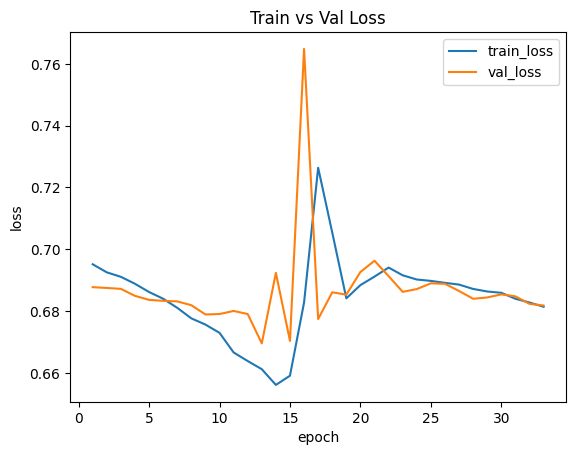

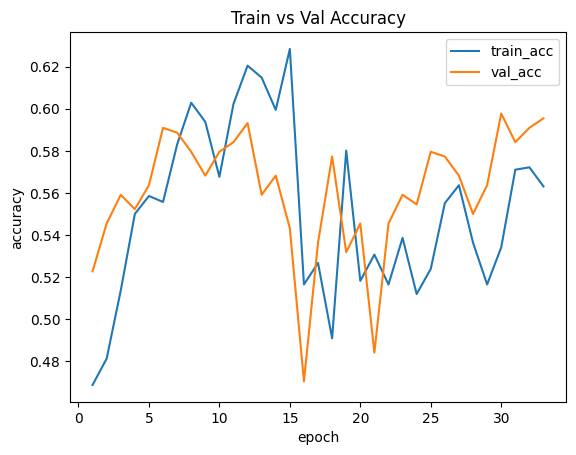

In [11]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().resolve().parents[0]

# Point this at your run folder (the same --workdir you used in training)
workdir = PROJECT_ROOT / Path("outputs")  # change if needed
metrics_path = workdir / "metrics.jsonl"

rows = []
with metrics_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows).sort_values("epoch")

# --- Plot losses together ---
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="train_loss")
plt.plot(df["epoch"], df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Train vs Val Loss")
plt.show()

# --- Plot accuracies together ---
plt.figure()
plt.plot(df["epoch"], df["train_acc"], label="train_acc")
plt.plot(df["epoch"], df["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Train vs Val Accuracy")
plt.show()


In [ ]:
from src.models.siamese import SiameseModel as model

model = model()
print('number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

number of parameters: 38951744
